<a href="https://colab.research.google.com/github/icosrle31/Test_ENNOH/blob/main/Zonal_inputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
packages installation

In [1]:
! pip install pypsa highspy

In [2]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)


Mounted at /content/drive


In [3]:
# Import packages
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypsa
import highspy

ROOT_DIR = os.getcwd()
PROJECT_DIR = os.path.join(ROOT_DIR, "drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/data")


# Input Data for Zone Modelling

In [4]:
country_name = 'Italy'
year = 2040
weather_profile = '2010.0'  # Historical weather shape to use


### Quantification - Annual Data


### Generation Capacities

In [5]:
# Define the list of Italian zones and initialize the capacities dictionary
italian_zones = ["ITSI", "ITSA", "ITS1", "ITN1", "ITCS", "ITCN", "ITCA"]
capacities = {}

In [6]:
def extract_zone_capacities_with_profiles(file_path):
    xls = pd.ExcelFile(file_path)
    zone_results = {}

    # 1. Horizontal Layout: Battery & Electrolyser
    for sheet in ['Battery', 'Electrolyser']:
        df = pd.read_excel(xls, sheet_name=sheet)
        params = df.iloc[6].dropna()
        vals = df.iloc[10].loc[params.index]
        zone_results[sheet] = dict(zip(params.values, vals.values))

    # 2. Solar
    df_solar = pd.read_excel(xls, sheet_name='Solar')
    solar_data = df_solar.iloc[7:12, 0:2].dropna()
    zone_results['Solar'] = dict(zip(solar_data.iloc[:, 0].astype(str), solar_data.iloc[:, 1]))

    # 3. Wind
    df_wind = pd.read_excel(xls, sheet_name='Wind')
    wind_data = df_wind.iloc[6:8, 0:2].dropna()
    zone_results['Wind'] = dict(zip(wind_data.iloc[:, 0].astype(str), wind_data.iloc[:, 1]))

    # 4. Hydro
    df_hydro = pd.read_excel(xls, sheet_name='Hydro', skiprows=5)
    valid_hydro = df_hydro.dropna(subset=[df_hydro.columns[0], df_hydro.columns[1]])
    zone_results['Hydro'] = dict(zip(valid_hydro.iloc[:, 0].astype(str), valid_hydro.iloc[:, 1]))

    # 5. Other RES: Capacity + Hourly Profile
    try:
        df_other_meta = pd.read_excel(xls, sheet_name='Other RES', header=None, nrows=9)
        other_name = str(df_other_meta.iloc[7, 0])
        other_val = df_other_meta.iloc[7, 1]

        df_profile = pd.read_excel(xls, sheet_name='Other RES', header=9)

        # Standardize datetime parsing for 2040
        dates = df_profile.iloc[:, 0].astype(str).str.strip()
        times = df_profile.iloc[:, 1].astype(int) - 1 # Convert 1-24 to 0-23

        # Construct datetime strings
        dt_combined = dates.apply(lambda x: x if x.endswith('.') else x + '.') + "2040 " + times.apply(lambda x: f"{x:02d}:00:00")
        df_profile['datetime'] = pd.to_datetime(dt_combined, format='%d.%m.%Y %H:%M:%S', errors='coerce')

        profile_series = df_profile.set_index('datetime').iloc[:, 2]

        zone_results['Other RES'] = {
            'capacity': {other_name: other_val},
            'profile': profile_series
        }
    except Exception as e:
        zone_results['Other RES'] = {'error': str(e)}

    return zone_results

# Run extraction for all zones
for zone in italian_zones:
    file_path = os.path.join(PROJECT_DIR, f"Italy/PEMMDB/PEMMDB_{zone}_NationalTrends_2040.xlsx")
    try:
        capacities[zone] = extract_zone_capacities_with_profiles(file_path)
        print(f"✅ Processed capacities for {zone}")
    except Exception as e:
        print(f"❌ Error processing {zone}: {e}")

✅ Processed capacities for ITSI
✅ Processed capacities for ITSA
✅ Processed capacities for ITS1
✅ Processed capacities for ITN1
✅ Processed capacities for ITCS
✅ Processed capacities for ITCN
✅ Processed capacities for ITCA


In [7]:
capacities

{'ITSI': {'Battery': {'Type': 'Battery',
   'Net maximum capacity - generation perspective \n(MW)': 4467,
   'Net maximum capacity - demand perspective \n(MW)': 4467,
   'Storage capacity \n(MWh)': 34088,
   'Number of units': 40,
   'Average efficiency': 0.9199999999999998,
   'Ramp up rate \n(MW/h)': 0,
   'Ramp down rate \n(MW/h)': 0},
  'Electrolyser': {'Type': 'Electrolyser',
   'Net maximum capacity \n(MW)': 1287.33,
   'Number of units': 2,
   'Average efficiency': 0.68,
   'H2 storage \n(GWh)': 0,
   'Ramp up rate \n(MW/h)': 0,
   'Ramp down rate \n(MW/h)': 0,
   'Fixed generation reduction (% of max power output)': 0},
  'Solar': {'Installed capacities Photovoltaic (GW):': 11.4,
   'Installed capacities Rooftop (GW):': 1.653698329299927,
   'Installed capacities Solar Thermal with Storage (GW):': 0,
   'Storage capacities Solar Thermal with Storage (GWh):': 0},
  'Wind': {'Installed capacities Onshore wind (GW):': 4.246,
   'Installed capacities Offshore wind (GW):': 3.2},
  '

#### Data Presentation

In [8]:
import pandas as pd

# Create a summary table for verification
summary_data = []
for zone, data in capacities.items():
    summary_data.append({
        'Zone': zone,
        'Solar PV (GW)': data['Solar'].get('Installed capacities Photovoltaic (GW):', 0),
        'Solar Rooftop (GW)': data['Solar'].get('Installed capacities Rooftop (GW):', 0),
        'Onshore Wind (GW)': data['Wind'].get('Installed capacities Onshore wind (GW):', 0),
        'Offshore Wind (GW)': data['Wind'].get('Installed capacities Offshore wind (GW):', 0),
        'Battery (MW)': data['Battery'].get('Net maximum capacity - generation perspective \n(MW)', 0),
        'Electrolyser (MW)': data['Electrolyser'].get('Net maximum capacity \n(MW)', 0),
        'Hydro RoR (MW)': data['Hydro'].get('Run of River - Total turbining capacity (MW)', 0)
    })

df_capacities_summary = pd.DataFrame(summary_data)
display(df_capacities_summary)

# Verify Other RES Profile consistency
print("\n--- Other RES Profile Verification ---")
for zone in italian_zones:
    if 'Other RES' in capacities[zone] and 'profile' in capacities[zone]['Other RES']:
        length = len(capacities[zone]['Other RES']['profile'])
        mean_val = capacities[zone]['Other RES']['profile'].mean()
        print(f"{zone}: Profile Length = {length}, Mean Output = {mean_val:.2f} MW")

,Zone,Solar PV (GW),Solar Rooftop (GW),Onshore Wind (GW),Offshore Wind (GW),Battery (MW),Electrolyser (MW),Hydro RoR (MW)
0,ITSI,11.400,1.653698,4.24600,3.2,4467.0,1287.33,91.92500
1,ITSA,9.504,0.717471,1.86000,2.6,2917.0,1758.50,81.90500
2,ITS1,17.266,2.057418,7.97800,6.2,6125.5,3835.39,50.03000
3,ITN1,16.000,16.495894,1.02200,0.9,5296.0,1115.69,5710.56310
4,ITCS,18.997,5.396503,5.49800,1.6,4702.1,858.22,696.77254
5,ITCN,4.600,2.608963,0.65900,2.3,1540.0,189.67,293.62000
6,ITCA,5.875,0.656597,1.80282,1.7,1863.0,955.20,125.38500



--- Other RES Profile Verification ---
ITSI: Profile Length = 8760, Mean Output = 55.29 MW
ITSA: Profile Length = 8760, Mean Output = 59.27 MW
ITS1: Profile Length = 8760, Mean Output = 265.70 MW
ITN1: Profile Length = 8760, Mean Output = 950.26 MW
ITCS: Profile Length = 8760, Mean Output = 324.02 MW
ITCN: Profile Length = 8760, Mean Output = 785.88 MW
ITCA: Profile Length = 8760, Mean Output = 107.48 MW


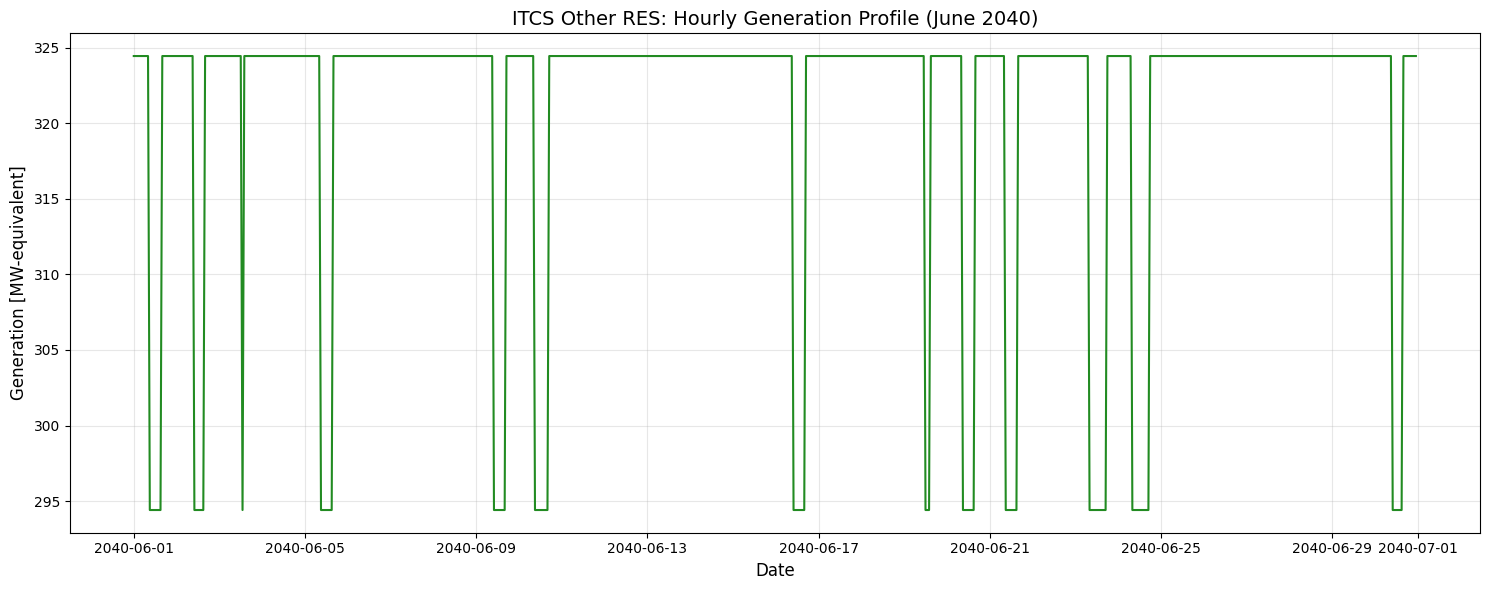

In [9]:
import matplotlib.pyplot as plt

if 'ITCS' in capacities and 'Other RES' in capacities['ITCS']:
    profile = capacities['ITCS']['Other RES']['profile']
    clean_profile = profile[profile.index.notnull()].sort_index()
    clean_profile = pd.to_numeric(clean_profile, errors='coerce')

    if not clean_profile.empty:
        june_profile = clean_profile.loc['2040-06-01':'2040-06-30']

        plt.figure(figsize=(15, 6))
        plt.plot(june_profile.index, june_profile.values, color='forestgreen', linewidth=1.5)
        plt.title('ITCS Other RES: Hourly Generation Profile (June 2040)', fontsize=14)
        plt.ylabel('Generation [MW-equivalent]', fontsize=12)
        plt.xlabel('Date', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Data cleaning resulted in an empty profile. Check source sheet structure.")
else:
    print('Error: ITCS Other RES data not found.')

### Solar Profile Extraction for Italian Zones (2010 Weather Shape)
This section processes the Rooftop and Utility PV capacity factors for all Italian zones, aligning them to the 2040 leap year.

In [10]:
# select yeart
weather_year = weather_profile

In [11]:
import pandas as pd
import numpy as np
import os

# Configuration
italy_data_dir = os.path.join(PROJECT_DIR, "Italy")
target_len = 8784  # 2040 Leap Year
time_index_2040 = pd.date_range(start="2040-01-01", periods=target_len, freq="h")

# Diagnostic: Find all CSV files recursively
all_csv_files = []
for root, dirs, files in os.walk(italy_data_dir):
    for file in files:
        if file.endswith('.csv'):
            all_csv_files.append(os.path.join(root, file))

print(f"✅ Found {len(all_csv_files)} CSV files in the directory and its subfolders.")
if len(all_csv_files) > 0:
    print("Example file found:", all_csv_files[0])

def adjust_to_2040_leap_year(profile_8760, target_index):
    """Adjusts 8760h data to 8784h by duplicating Feb 28th for Feb 29th."""
    arr = np.array(profile_8760)
    feb_29_start = 59 * 24
    feb_28_start = 58 * 24
    feb_28_data = arr[feb_28_start : feb_28_start + 24]

    new_arr = np.zeros(8784)
    new_arr[:feb_29_start] = arr[:feb_29_start]
    new_arr[feb_29_start : feb_29_start + 24] = feb_28_data
    new_arr[feb_29_start + 24 :] = arr[feb_28_start + 24 :]
    return new_arr

# Initialize container for profiles
solar_profiles_df = pd.DataFrame(index=time_index_2040)

for zone in italian_zones:
    for tech in ["Rooftop", "Utility"]:
        # Find the specific file for this zone and technology
        # Looking for files containing both strings (e.g., 'ITSI' and 'Rooftop')
        matches = [f for f in all_csv_files if zone in f and tech in f]

        if not matches:
            print(f"❌ No file found for {zone} {tech}")
            continue

        file_path = matches[0]

        try:
            # Read CSV (PECD files typically have 10 header rows)
            df_raw = pd.read_csv(file_path, header=10, usecols=[weather_year])
            profile_8760 = df_raw[weather_year].astype(float)

            # Adjust for leap year
            profile_8784 = adjust_to_2040_leap_year(profile_8760, time_index_2040)

            # Add to DataFrame
            col_name = f"{zone}_{tech}_PV"
            solar_profiles_df[col_name] = profile_8784
            print(f"✅ Processed {col_name} (File: {os.path.basename(file_path)})")

        except Exception as e:
            print(f"❌ Error processing {os.path.basename(file_path)}: {e}")

display(solar_profiles_df.head())
print(f"\nFinal Solar Profiles DataFrame Shape: {solar_profiles_df.shape}")

✅ Found 43 CSV files in the directory and its subfolders.
Example file found: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/data/Italy/Italy_profile_2040.csv
✅ Processed ITSI_Rooftop_PV (File: PECD_LFSolarPVRooftop_2040_ITSI_edition 2023.2.csv)
✅ Processed ITSI_Utility_PV (File: PECD_LFSolarPVUtility_2040_ITSI_edition 2023.2.csv)
✅ Processed ITSA_Rooftop_PV (File: PECD_LFSolarPVRooftop_2040_ITSA_edition 2023.2.csv)
✅ Processed ITSA_Utility_PV (File: PECD_LFSolarPVUtility_2040_ITSA_edition 2023.2.csv)
✅ Processed ITS1_Rooftop_PV (File: PECD_LFSolarPVRooftop_2040_ITS1_edition 2023.2.csv)
✅ Processed ITS1_Utility_PV (File: PECD_LFSolarPVUtility_2040_ITS1_edition 2023.2.csv)
✅ Processed ITN1_Rooftop_PV (File: PECD_LFSolarPVRooftop_2040_ITN1_edition 2023.2.csv)
✅ Processed ITN1_Utility_PV (File: PECD_LFSolarPVUtility_2040_ITN1_edition 2023.2.csv)
✅ Processed ITCS_Rooftop_PV (File: PECD_LFSolarPVRooftop_2040_ITCS_edition 2023.2.csv)
✅ Processed ITCS_Utility_PV (File: PECD_LFSolarP

,ITSI_Rooftop_PV,ITSI_Utility_PV,ITSA_Rooftop_PV,ITSA_Utility_PV,ITS1_Rooftop_PV,ITS1_Utility_PV,ITN1_Rooftop_PV,ITN1_Utility_PV,ITCS_Rooftop_PV,ITCS_Utility_PV,ITCN_Rooftop_PV,ITCN_Utility_PV,ITCA_Rooftop_PV,ITCA_Utility_PV
2040-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2040-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2040-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2040-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2040-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Final Solar Profiles DataFrame Shape: (8784, 14)


In [12]:
# --- Wind Profile Extraction for Italian Zones (Onshore & Offshore) ---
wind_profiles_df = pd.DataFrame(index=time_index_2040)

# Technologies to search for
wind_techs = ["Wind_Onshore", "Wind_Offshore"]

for zone in italian_zones:
    for tech in wind_techs:
        # Find the specific file for this zone and technology
        matches = [f for f in all_csv_files if zone in f and tech in f]

        if not matches:
            continue

        file_path = matches[0]

        try:
            # Read headers first to check for '2010.0' vs '2010'
            df_temp = pd.read_csv(file_path, header=10, nrows=0)
            actual_col = weather_year if weather_year in df_temp.columns else str(int(float(weather_year)))

            if actual_col not in df_temp.columns:
                print(f"⚠️ Column {weather_year} or {actual_col} not found in {os.path.basename(file_path)}")
                continue

            # Read the full column
            df_raw = pd.read_csv(file_path, header=10, usecols=[actual_col])
            profile_8760 = df_raw[actual_col].astype(float)

            # Adjust for leap year
            profile_8784 = adjust_to_2040_leap_year(profile_8760, time_index_2040)

            # Add to DataFrame
            col_name = f"{zone}_{tech}"
            wind_profiles_df[col_name] = profile_8784
            print(f"✅ Processed {col_name} (File: {os.path.basename(file_path)})")

        except Exception as e:
            print(f"❌ Error processing {os.path.basename(file_path)}: {e}")

display(wind_profiles_df.head())
print(f"\nFinal Wind Profiles DataFrame Shape: {wind_profiles_df.shape}")

✅ Processed ITSI_Wind_Onshore (File: PECD_Wind_Onshore_2040_ITSI_edition 2023.2.csv)
✅ Processed ITSI_Wind_Offshore (File: PECD_Wind_Offshore_2040_ITSIOR1_edition 2023.2.csv)
✅ Processed ITSA_Wind_Onshore (File: PECD_Wind_Onshore_2040_ITSA_edition 2023.2.csv)
✅ Processed ITSA_Wind_Offshore (File: PECD_Wind_Offshore_2040_ITSAOR1_edition 2023.2.csv)
✅ Processed ITS1_Wind_Onshore (File: PECD_Wind_Onshore_2040_ITS1_edition 2023.2.csv)
✅ Processed ITS1_Wind_Offshore (File: PECD_Wind_Offshore_2040_ITS1_edition 2023.2.csv)
✅ Processed ITN1_Wind_Onshore (File: PECD_Wind_Onshore_2040_ITN1_edition 2023.2.csv)
✅ Processed ITN1_Wind_Offshore (File: PECD_Wind_Offshore_2040_ITN1OR1_edition 2023.2.csv)
✅ Processed ITCS_Wind_Onshore (File: PECD_Wind_Onshore_2040_ITCS_edition 2023.2.csv)
✅ Processed ITCS_Wind_Offshore (File: PECD_Wind_Offshore_2040_ITCS_edition 2023.2.csv)
✅ Processed ITCN_Wind_Onshore (File: PECD_Wind_Onshore_2040_ITCN_edition 2023.2.csv)
✅ Processed ITCN_Wind_Offshore (File: PECD_Win

,ITSI_Wind_Onshore,ITSI_Wind_Offshore,ITSA_Wind_Onshore,ITSA_Wind_Offshore,ITS1_Wind_Onshore,ITS1_Wind_Offshore,ITN1_Wind_Onshore,ITN1_Wind_Offshore,ITCS_Wind_Onshore,ITCS_Wind_Offshore,ITCN_Wind_Onshore,ITCN_Wind_Offshore,ITCA_Wind_Onshore,ITCA_Wind_Offshore
2040-01-01 00:00:00,0.478309,0.827320,0.870680,0.937479,0.674779,0.927566,0.030658,0.285059,0.863222,0.836899,0.340203,0.809939,0.676296,0.927566
2040-01-01 01:00:00,0.582580,0.601922,0.853234,0.944088,0.711096,0.904453,0.043738,0.159539,0.843935,0.807073,0.271373,0.802190,0.714382,0.904453
2040-01-01 02:00:00,0.539000,0.522901,0.855503,0.927213,0.741099,0.877913,0.043421,0.062635,0.821750,0.851161,0.318158,0.828064,0.746267,0.877913
2040-01-01 03:00:00,0.503899,0.569597,0.868317,0.932883,0.754899,0.842565,0.042045,0.039201,0.832883,0.911781,0.414378,0.830716,0.759609,0.842565
2040-01-01 04:00:00,0.542123,0.613490,0.880070,0.934689,0.761231,0.792828,0.040956,0.157061,0.843833,0.922692,0.498035,0.817136,0.764085,0.792828



Final Wind Profiles DataFrame Shape: (8784, 14)


#### Data Visualisation

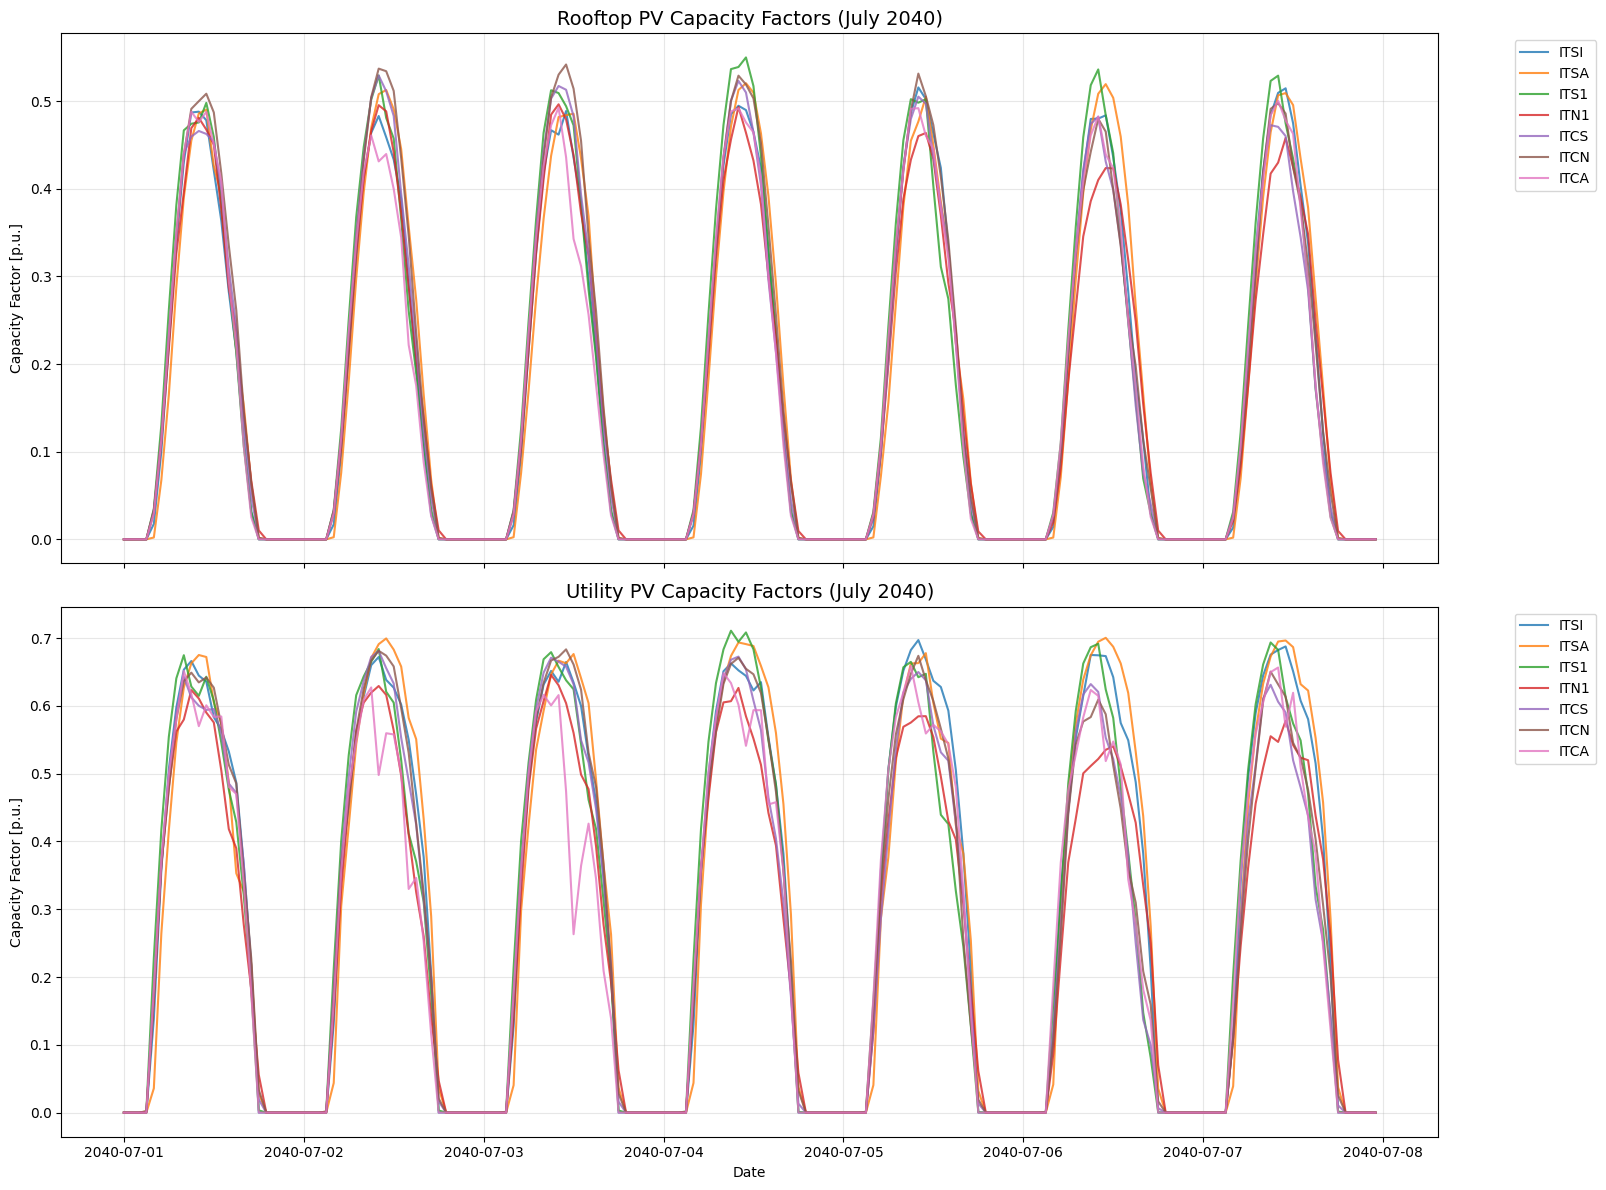

In [13]:
import matplotlib.pyplot as plt

# Set up a combined visualization for Solar profiles
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

start_date = '2040-07-01'
end_date = '2040-07-07'

# Plot Rooftop PV
rooftop_cols = [c for c in solar_profiles_df.columns if "Rooftop" in c]
for col in rooftop_cols:
    data = solar_profiles_df.loc[start_date:end_date, col]
    axes[0].plot(data.index, data.values, label=col.split('_')[0], alpha=0.8)

axes[0].set_title("Rooftop PV Capacity Factors (July 2040)", fontsize=14)
axes[0].set_ylabel("Capacity Factor [p.u.]")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', bbox_to_anchor=(1.12, 1))

# Plot Utility PV
utility_cols = [c for c in solar_profiles_df.columns if "Utility" in c]
for col in utility_cols:
    data = solar_profiles_df.loc[start_date:end_date, col]
    axes[1].plot(data.index, data.values, label=col.split('_')[0], alpha=0.8)

axes[1].set_title("Utility PV Capacity Factors (July 2040)", fontsize=14)
axes[1].set_ylabel("Capacity Factor [p.u.]")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right', bbox_to_anchor=(1.12, 1))

plt.tight_layout()
plt.show()

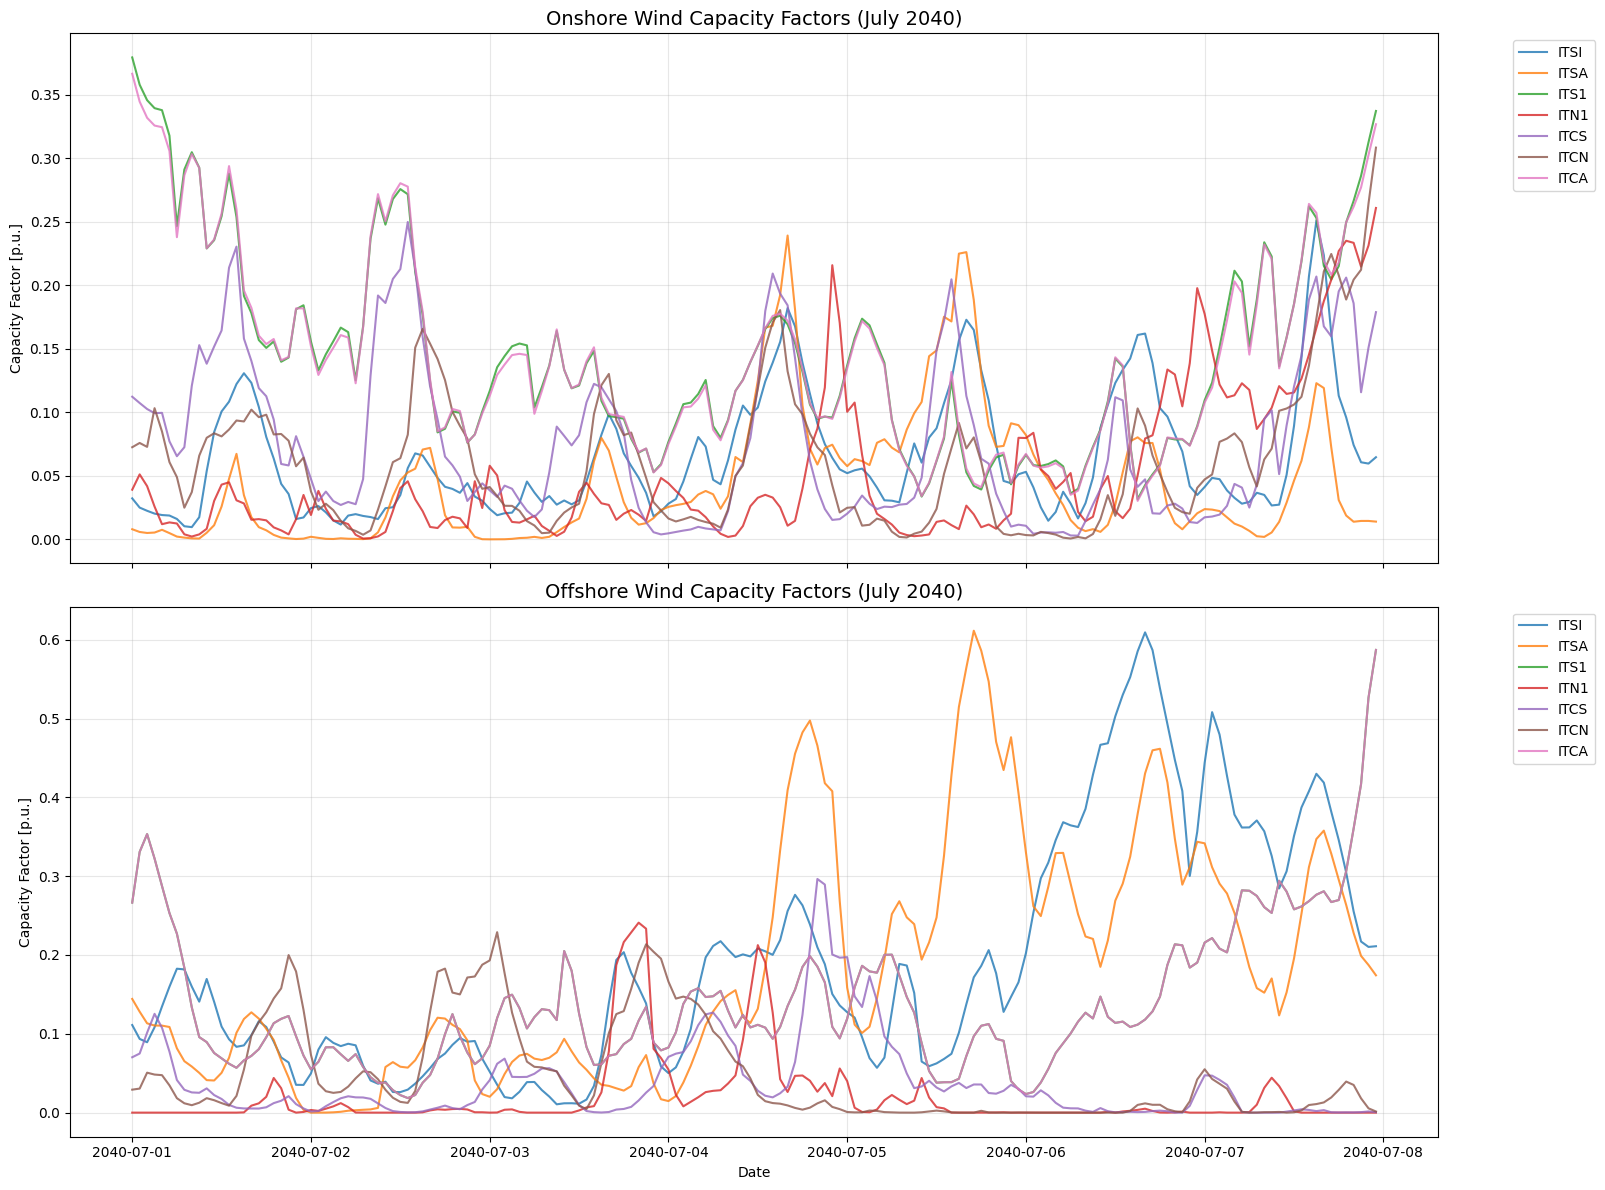

In [14]:
import matplotlib.pyplot as plt

# Set up a combined visualization for Wind profiles
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Correcting the slicing syntax
start_date = '2040-07-01'
end_date = '2040-07-07'

# Plot Onshore Wind
onshore_cols = [c for c in wind_profiles_df.columns if "Onshore" in c]
for col in onshore_cols:
    data = wind_profiles_df.loc[start_date:end_date, col]
    axes[0].plot(data.index, data.values, label=col.split('_')[0], alpha=0.8)

axes[0].set_title("Onshore Wind Capacity Factors (July 2040)", fontsize=14)
axes[0].set_ylabel("Capacity Factor [p.u.]")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', bbox_to_anchor=(1.12, 1))

# Plot Offshore Wind
offshore_cols = [c for c in wind_profiles_df.columns if "Offshore" in c]
for col in offshore_cols:
    data = wind_profiles_df.loc[start_date:end_date, col]
    axes[1].plot(data.index, data.values, label=col.split('_')[0], alpha=0.8)

axes[1].set_title("Offshore Wind Capacity Factors (July 2040)", fontsize=14)
axes[1].set_ylabel("Capacity Factor [p.u.]")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right', bbox_to_anchor=(1.12, 1))

plt.tight_layout()
plt.show()

In [15]:
# Capacities in Selected contry
try:
    Nat_trends_file_path = os.path.join(PROJECT_DIR, "PEMMDB_SI00_NationalTrends_2040.xlsx")
    xls_pemmdb = pd.ExcelFile(Nat_trends_file_path)

    # 1. Solar Extraction
    df_solar_raw = pd.read_excel(xls_pemmdb, sheet_name='Solar', header=None)
    solar_rooftop = float(df_solar_raw.iloc[9, 1]) * 1000
    solar_pv = float(df_solar_raw.iloc[8, 1]) * 1000
    solar_p_nom = solar_pv + solar_rooftop

    # 2. Wind Extraction
    df_wind_raw = pd.read_excel(xls_pemmdb, sheet_name='Wind', header=None)
    wind_p_nom = float(df_wind_raw.iloc[7, 1]) * 1000

    # 3. Hydro Extraction (RoR and Pondage)
    df_hydro = pd.read_excel(xls_pemmdb, sheet_name='Hydro', header=None)

    # Extract Run of River
    ror_row = df_hydro[df_hydro.iloc[:, 0].astype(str).str.contains('Run of River - Total turbining', case=False, na=False)]
    ror_p_nom = float(ror_row.iloc[0, 1]) if not ror_row.empty else 0.0

    # Extract Pondage
    pondage_row = df_hydro[df_hydro.iloc[:, 0].astype(str).str.contains('Pondage - Total turbining capacity', case=False, na=False)]
    pondage_p_nom = float(pondage_row.iloc[0, 1]) if not pondage_row.empty else 1088.3

    hydro_total_p_nom = ror_p_nom + pondage_p_nom

except Exception as e:
    print(f"❌ Error extracting from specific cells: {e}")

In [16]:

# --- 1. LOAD DATA FROM EXCEL ---
try:
    # Define the input file path directly to ensure execution works


    # --- 3. OPTIMIZATION INPUTS CONSOLIDATION ---
    # Using total_elec and total_h2 from Step 1 (cell FCStHXRyIOic)
    optimization_inputs = {
        'country': country_name,
        'year': year,
        'annual_elec_demand_twh': total_elec,
        'annual_h2_demand_twh': total_h2,
        'p2g_target_mw': annual_inputs['p2g_capacity_mw'],
        'total_methane_demand_twh': annual_inputs['methane_demand_twh'],
        'biomethane_potential_twh': annual_inputs['biomethane_potential_twh'],
        'battery_capacity_mw': float(battery_database.loc['SI', 'Capacity (MW)']),
        'battery_storage_mwh': float(battery_database.loc['SI', 'Storage Capacity (MWh)']),
        'battery_efficiency': float(battery_database.loc['SI', 'Average Efficiency']),
        'synthetic_methane_share': annual_inputs['synthetic_methane_fraction']
    }

    print("--- Final Optimization Inputs Summary ---")
    for key, value in optimization_inputs.items():
        if isinstance(value, float):
            print(f"{key:25}: {value:.2f}")
        else:
            print(f"{key:25}: {value}")

except Exception as e:
    print(f"❌ Error preparing optimization inputs: {e}")

❌ Error preparing optimization inputs: name 'total_elec' is not defined


In [17]:
# Extract pondage capacity from df_hydro

# --- Slovenia 2040 Generation Capacities (Original Version) ---
elec_generators = {
    "Solar":   {"p_nom": np.round(solar_p_nom,1), "marginal_cost": 0.01, "carrier": "solar"},
    "Nuclear": {"p_nom": 696.0,  "marginal_cost": 12.0, "carrier": "nuclear"},
    "Hydro":   {"p_nom": np.round(hydro_total_p_nom, 1), "marginal_cost": 0.5,  "carrier": "hydro"},
    "Coal":    {"p_nom": 540.0,  "marginal_cost": 95.0, "carrier": "coal"},
    "Wind":    {"p_nom": np.round(wind_p_nom,1),   "marginal_cost": 0.01, "carrier": "wind"}
}

print("✅ Generation capacities successfully restored:")
for name, info in elec_generators.items():
    print(f"- {name}: {info['p_nom']} MW")

✅ Generation capacities successfully restored:
- Solar: 5250.0 MW
- Nuclear: 696.0 MW
- Hydro: 1228.9 MW
- Coal: 540.0 MW
- Wind: 305.5 MW




## Hydro data

### Run-of-river

In [18]:
import pandas as pd
import numpy as np
import os

# Configuration
italy_hydro_dir = os.path.join(PROJECT_DIR, "Italy/Hydro")
target_hours = 8784
time_index_2040 = pd.date_range(start="2040-01-01", periods=target_hours, freq="h")
weather_year_int = int(float(weather_profile))

# Initialize container for profiles
ror_inflow_df = pd.DataFrame(index=time_index_2040)

def force_align_8784(data):
    arr = np.array(data)
    return np.pad(arr, (0, max(0, target_hours - len(arr))), mode='edge')[:target_hours]

# Iterate through zones and find their specific inflow files
for zone in italian_zones:
    # Find files matching the zone name in the Hydro directory
    zone_inflow_files = [os.path.join(italy_hydro_dir, f) for f in os.listdir(italy_hydro_dir)
                         if zone in f and "Inflow" in f and f.endswith('.xlsx')]

    if not zone_inflow_files:
        print(f"☐ No specific inflow file found for {zone} in {italy_hydro_dir}")
        continue

    file_path = zone_inflow_files[0]
    try:
        xls = pd.ExcelFile(file_path)
        # Typically 'Run of River - Year Dependent' in these files
        sheet_name = next((s for s in xls.sheet_names if "Run of River" in s and "Year" in s), xls.sheet_names[0])

        df_raw = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        # Find the weather year column (2010)
        header_rows = df_raw.iloc[:10]
        target_col = None
        for i, row in header_rows.iterrows():
            matches = row[row == weather_year_int].index.tolist()
            if matches:
                target_col = matches[0]
                break

        if target_col is not None:
            # Get capacity from the 'capacities' dictionary processed earlier
            p_nom_ror = capacities.get(zone, {}).get('Hydro', {}).get('Run of River - Total turbining capacity (MW)', 1.0)
            if p_nom_ror == 0: p_nom_ror = 1.0 # Avoid division by zero

            daily_inflow_gwh = df_raw.iloc[5:, target_col].astype(float).dropna()
            hourly_mw = (daily_inflow_gwh * 1000 / 24).repeat(24).values
            inflow_pu = force_align_8784(hourly_mw) / p_nom_ror

            ror_inflow_df[f"{zone}_RoR_Inflow_pu"] = inflow_pu
            print(f"✅ Processed {zone} from {os.path.basename(file_path)}")
        else:
            print(f"☐ Could not find year {weather_year_int} in {os.path.basename(file_path)}")

    except Exception as e:
        print(f"❌ Error processing {zone}: {e}")

display(ror_inflow_df.head())
print(f"Final Profiles Shape: {ror_inflow_df.shape}")

✅ Processed ITSI from PEMMDB_ITSI_Hydro_Inflows_2040.xlsx
✅ Processed ITSA from PEMMDB_ITSA_Hydro_Inflows_2040.xlsx
✅ Processed ITS1 from PEMMDB_ITS1_Hydro_Inflows_2040.xlsx
✅ Processed ITN1 from PEMMDB_ITN1_Hydro_Inflows_2040.xlsx
✅ Processed ITCS from PEMMDB_ITCS_Hydro_Inflows_2040.xlsx
✅ Processed ITCN from PEMMDB_ITCN_Hydro_Inflows_2040.xlsx
✅ Processed ITCA from PEMMDB_ITCA_Hydro_Inflows_2040.xlsx


,ITSI_RoR_Inflow_pu,ITSA_RoR_Inflow_pu,ITS1_RoR_Inflow_pu,ITN1_RoR_Inflow_pu,ITCS_RoR_Inflow_pu,ITCN_RoR_Inflow_pu,ITCA_RoR_Inflow_pu
2040-01-01 00:00:00,0.221814,0.299161,0.0,0.274829,0.601657,0.431623,0.327778
2040-01-01 01:00:00,0.221814,0.299161,0.0,0.274829,0.601657,0.431623,0.327778
2040-01-01 02:00:00,0.221814,0.299161,0.0,0.274829,0.601657,0.431623,0.327778
2040-01-01 03:00:00,0.221814,0.299161,0.0,0.274829,0.601657,0.431623,0.327778
2040-01-01 04:00:00,0.221814,0.299161,0.0,0.274829,0.601657,0.431623,0.327778


Final Profiles Shape: (8784, 7)


#### Data presentation

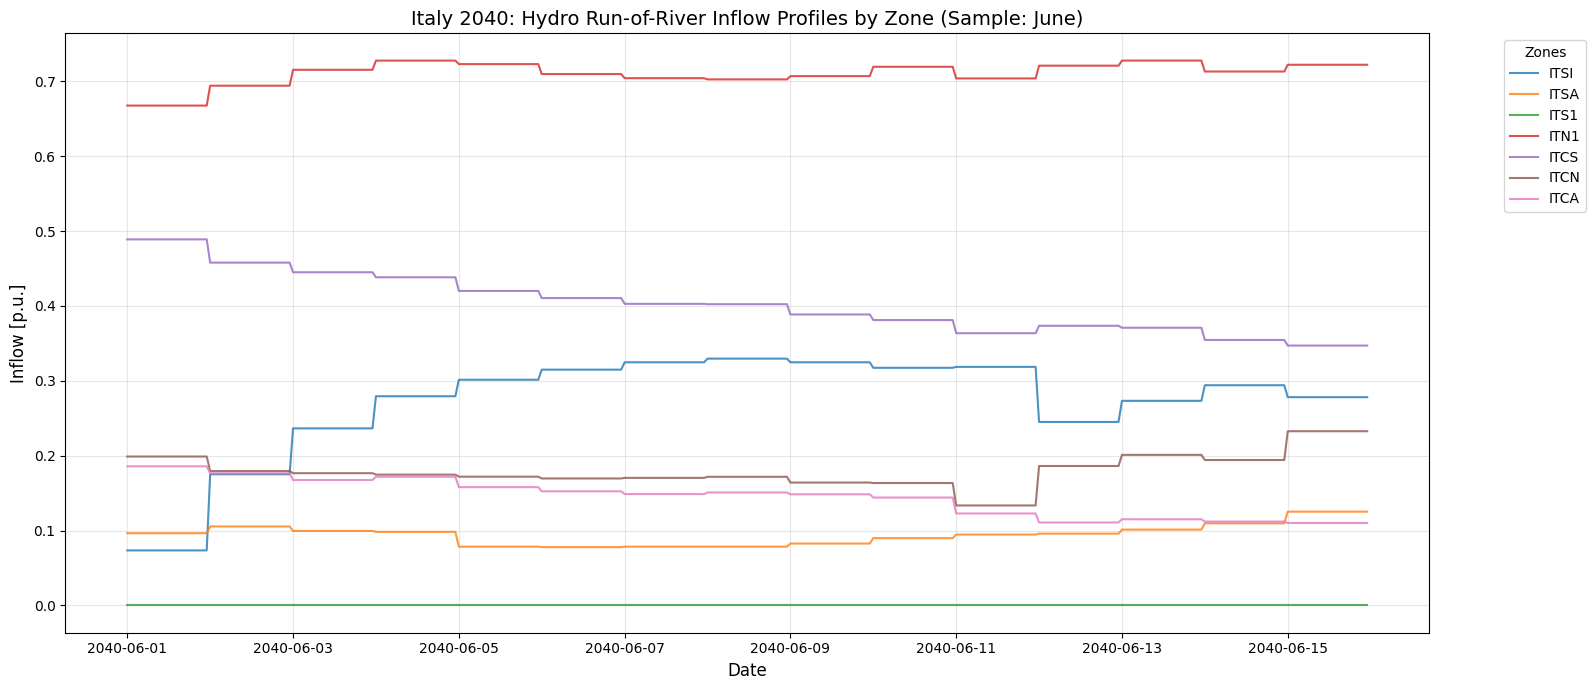

--- Average Annual RoR Inflow (p.u.) ---


,Mean Inflow (p.u.)
ITSI_RoR_Inflow_pu,0.357425
ITSA_RoR_Inflow_pu,0.185096
ITS1_RoR_Inflow_pu,0.000000
ITN1_RoR_Inflow_pu,0.406294
ITCS_RoR_Inflow_pu,0.457829
ITCN_RoR_Inflow_pu,0.258792
ITCA_RoR_Inflow_pu,0.194284


In [19]:
import matplotlib.pyplot as plt

# Visualize the RoR Inflow profiles for all 7 zones
plt.figure(figsize=(16, 7))

# Selecting June 2040 for clear visualization
start_date = '2040-06-01'
end_date = '2040-06-15'

for col in ror_inflow_df.columns:
    zone_label = col.replace('_RoR_Inflow_pu', '')
    data_sample = ror_inflow_df.loc[start_date:end_date, col]
    plt.plot(data_sample.index, data_sample.values, label=zone_label, alpha=0.8, linewidth=1.5)

plt.title(f'Italy {year}: Hydro Run-of-River Inflow Profiles by Zone (Sample: June)', fontsize=14)
plt.ylabel('Inflow [p.u.]', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(title='Zones', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics for all zones
print("--- Average Annual RoR Inflow (p.u.) ---")
display(ror_inflow_df.mean().to_frame(name='Mean Inflow (p.u.)'))

### Pondage

In [20]:
import pandas as pd
import numpy as np
import os

# Container for Pondage profiles
pondage_inflow_df = pd.DataFrame(index=time_index_2040)
pondage_capacities = {}

for zone in italian_zones:
    zone_inflow_files = [os.path.join(italy_hydro_dir, f) for f in os.listdir(italy_hydro_dir)
                         if zone in f and "Inflow" in f and f.endswith('.xlsx')]

    if not zone_inflow_files:
        continue

    file_path = zone_inflow_files[0]
    try:
        xls = pd.ExcelFile(file_path)
        # Identify Pondage sheet
        sheet_name = next((s for s in xls.sheet_names if "Pondage" in s and "Year" in s), None)

        if not sheet_name:
            print(f"☐ No Pondage sheet found for {zone} in {os.path.basename(file_path)}")
            continue

        df_raw = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        # Find 2010 column
        header_rows = df_raw.iloc[:10]
        target_col = None
        for i, row in header_rows.iterrows():
            matches = row[row == weather_year_int].index.tolist()
            if matches:
                target_col = matches[0]
                break

        if target_col is not None:
            # Get capacity from the 'capacities' dictionary (processed in the first step of the notebook)
            p_nom_pond = capacities.get(zone, {}).get('Hydro', {}).get('Pondage - Total turbining capacity (MW)', 0.0)

            if p_nom_pond > 0:
                daily_inflow_gwh = df_raw.iloc[5:, target_col].astype(float).dropna()
                hourly_mw = (daily_inflow_gwh * 1000 / 24).repeat(24).values
                inflow_pu = force_align_8784(hourly_mw) / p_nom_pond

                pondage_inflow_df[f"{zone}_Pondage_Inflow_pu"] = inflow_pu
                pondage_capacities[zone] = p_nom_pond
                print(f"✅ Processed Pondage for {zone} (Cap: {p_nom_pond} MW)")
            else:
                print(f"☐ {zone} has 0 MW Pondage capacity.")
        else:
             print(f"☐ Could not find year {weather_year_int} in Pondage sheet for {zone}")

    except Exception as e:
        print(f"❌ Error processing Pondage for {zone}: {e}")

display(pondage_inflow_df.head())
print(f"Final Pondage Profiles Shape: {pondage_inflow_df.shape}")

☐ ITSI has 0 MW Pondage capacity.
☐ ITSA has 0 MW Pondage capacity.
☐ ITS1 has 0 MW Pondage capacity.
☐ ITN1 has 0 MW Pondage capacity.
☐ ITCS has 0 MW Pondage capacity.
☐ ITCN has 0 MW Pondage capacity.
☐ ITCA has 0 MW Pondage capacity.


""
2040-01-01 00:00:00
2040-01-01 01:00:00
2040-01-01 02:00:00
2040-01-01 03:00:00
2040-01-01 04:00:00


Final Pondage Profiles Shape: (8784, 0)


### Reservoir

In [21]:
import pandas as pd
import os
import numpy as np

weekly_reservoir_stats = {}
overall_summary = []
weather_year_int = int(float(weather_profile))

for zone in italian_zones:
    matches = [os.path.join(italy_hydro_dir, f) for f in os.listdir(italy_hydro_dir) if zone in f and "Inflow" in f]
    if not matches: continue

    file_path = matches[0]
    try:
        xls = pd.ExcelFile(file_path)
        sheet_uni = next((s for s in xls.sheet_names if "Reservoir" in s and "Uniform" in s), None)
        sheet_year = next((s for s in xls.sheet_names if "Reservoir" in s and "Year" in s), None)

        if sheet_uni and sheet_year:
            # 1. Weekly Inflows
            df_year = pd.read_excel(xls, sheet_name=sheet_year, header=None)

            # Find the header row containing the weather years
            header_rows = df_year.iloc[:10]
            target_col = None
            for idx, row in header_rows.iterrows():
                if weather_year_int in row.values:
                    target_col = row[row == weather_year_int].index[0]
                    break

            if target_col is not None:
                # Extract the 53 weeks for the target year and handle missing values
                weekly_inflow_gwh = df_year.iloc[2:55, target_col].astype(float).ffill().fillna(0)
                n_weeks = len(weekly_inflow_gwh)

                # Convert GWh/week to Average MW (168 hours in a week)
                weekly_inflow_mw = weekly_inflow_gwh.values * 1000 / 168

                # 2. Extract constraints from Uniform sheet
                df_uni = pd.read_excel(xls, sheet_name=sheet_uni, header=None)
                try:
                    # P_NOM_TURB is typically at Row 8, Col 1
                    max_val = float(df_uni.iloc[8, 1])
                    min_val = 0.0
                except:
                    max_val = capacities.get(zone, {}).get('Hydro', {}).get('Reservoir - Total turbining capacity (MW)', 0.0)
                    min_val = 0.0

                zone_df = pd.DataFrame({
                    'Min_MW': [min_val] * n_weeks,
                    'Max_MW': [max_val] * n_weeks,
                    'Inflow_MW': weekly_inflow_mw
                }, index=range(1, n_weeks + 1))

                weekly_reservoir_stats[zone] = zone_df
                overall_summary.append({
                    'Zone': zone,
                    'Weeks': n_weeks,
                    'Avg Inflow (MW)': weekly_inflow_mw.mean()
                })
                print(f"✅ Processed {zone}: Extracted exactly {n_weeks} weeks.")
            else:
                print(f"☐ Year {weather_year_int} not found in {os.path.basename(file_path)}")

    except Exception as e:
        print(f"❌ Error processing {zone}: {e}")

df_res_summary = pd.DataFrame(overall_summary)
display(df_res_summary)


✅ Processed ITSI: Extracted exactly 53 weeks.
✅ Processed ITSA: Extracted exactly 53 weeks.
✅ Processed ITS1: Extracted exactly 53 weeks.
✅ Processed ITN1: Extracted exactly 53 weeks.
✅ Processed ITCS: Extracted exactly 53 weeks.
✅ Processed ITCN: Extracted exactly 53 weeks.
✅ Processed ITCA: Extracted exactly 53 weeks.


,Zone,Weeks,Avg Inflow (MW)
0,ITSI,53,4.476220
1,ITSA,53,35.204026
2,ITS1,53,43.065006
3,ITN1,53,1520.759079
4,ITCS,53,213.060172
5,ITCN,53,66.204446
6,ITCA,53,155.110880


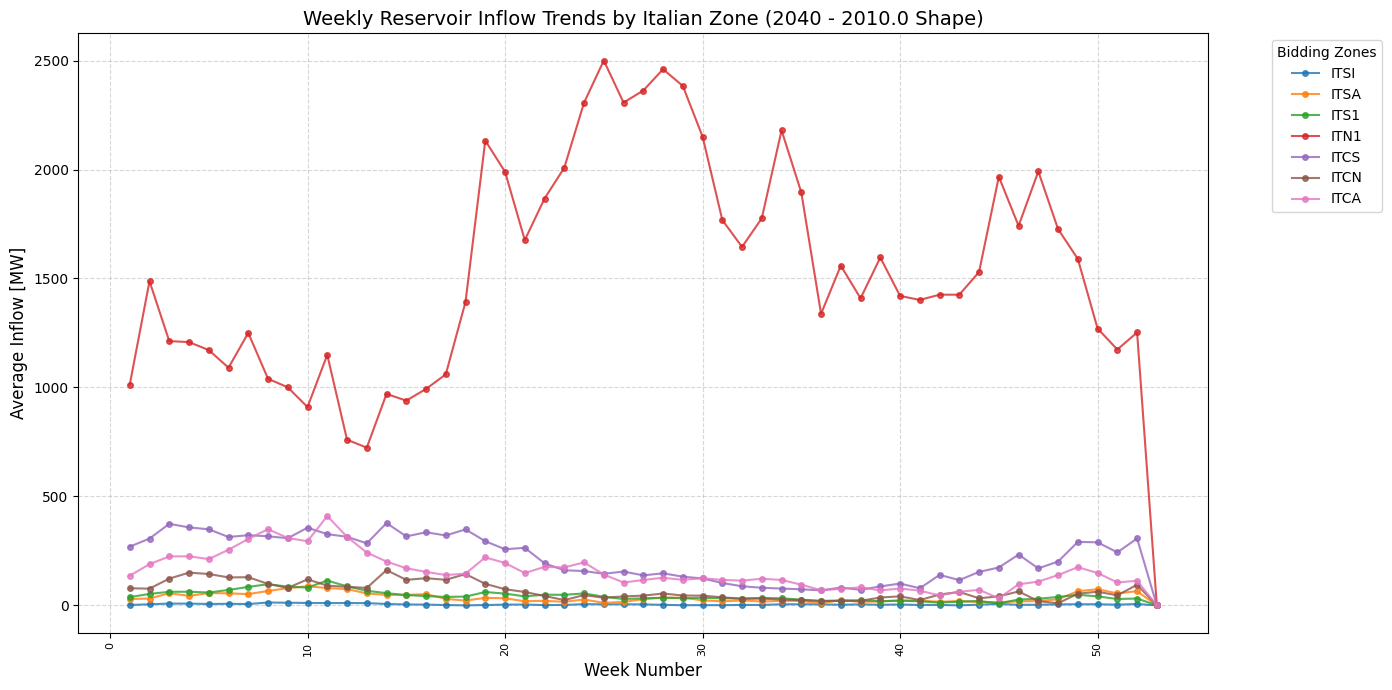

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Recreate the weekly inflows DataFrame since it was deleted
weekly_inflows_all_zones = pd.DataFrame({
    zone: df['Inflow_MW'] for zone, df in weekly_reservoir_stats.items()
})

if not weekly_inflows_all_zones.empty:
    plt.figure(figsize=(14, 7))

    # Plot each zone's weekly inflow
    for column in weekly_inflows_all_zones.columns:
        plt.plot(weekly_inflows_all_zones.index, weekly_inflows_all_zones[column],
                 marker='o', markersize=4, label=column, alpha=0.8)

    plt.title(f'Weekly Reservoir Inflow Trends by Italian Zone ({year} - {weather_profile} Shape)', fontsize=14)
    plt.xlabel('Week Number', fontsize=12)
    plt.ylabel('Average Inflow [MW]', fontsize=12)
    plt.legend(title='Bidding Zones', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    # Since there are many weeks, rotate x-ticks for better readability
    plt.xticks(rotation=90, fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot.")


In [23]:
import pandas as pd
import os

reservoir_constraints = []

for zone in italian_zones:
    # Find the specific hydro inflow file for the zone
    matches = [os.path.join(italy_hydro_dir, f) for f in os.listdir(italy_hydro_dir) if zone in f and "Inflow" in f]

    if not matches:
        print(f"☐ No Hydro file found for {zone}")
        continue

    file_path = matches[0]
    try:
        xls = pd.ExcelFile(file_path)
        sheet_uni = next((s for s in xls.sheet_names if "Reservoir" in s and "Uniform" in s), None)

        if sheet_uni:
            df_uni = pd.read_excel(xls, sheet_name=sheet_uni, header=None)

            # Try to extract the turbine constraints
            try:
                # In PEMMDB, P_NOM_TURB is usually recorded at Row 8, Col 1
                max_val = float(df_uni.iloc[8, 1])
                min_val = 0.0 # PEMMDB typically assumes 0 MW as minimum
            except Exception:
                # Fallback to previously extracted capacities if cell extraction fails
                max_val = capacities.get(zone, {}).get('Hydro', {}).get('Reservoir - Total turbining capacity (MW)', 0.0)
                min_val = 0.0

            reservoir_constraints.append({
                'Zone': zone,
                'Min Turbine (MW)': min_val,
                'Max Turbine (MW)': max_val
            })
            print(f"✅ Extracted constraints for {zone}")
        else:
            print(f"☐ 'Reservoir - Uniform' sheet not found for {zone}")

    except Exception as e:
        print(f"❌ Error extracting constraints for {zone}: {e}")

df_reservoir_constraints = pd.DataFrame(reservoir_constraints)
print("\n--- Reservoir Turbine Constraints ---")
display(df_reservoir_constraints)


✅ Extracted constraints for ITSI
✅ Extracted constraints for ITSA
✅ Extracted constraints for ITS1
✅ Extracted constraints for ITN1
✅ Extracted constraints for ITCS
✅ Extracted constraints for ITCN
✅ Extracted constraints for ITCA

--- Reservoir Turbine Constraints ---


,Zone,Min Turbine (MW),Max Turbine (MW)
0,ITSI,0.0,42.3400
1,ITSA,0.0,153.3975
2,ITS1,0.0,178.2700
3,ITN1,0.0,6344.9740
4,ITCS,0.0,1005.1160
5,ITCN,0.0,389.2700
6,ITCA,0.0,701.2840


In [24]:
import pandas as pd
import numpy as np

# Initialize the hourly reservoir profiles DataFrame
reservoir_profiles_df = pd.DataFrame(index=time_index_2040)
target_hours = len(time_index_2040)

for zone, df_weekly in weekly_reservoir_stats.items():
    # 1. Repeat each weekly value 168 times (number of hours in a standard week)
    min_mw_hourly = np.repeat(df_weekly['Min_MW'].values, 168)
    max_mw_hourly = np.repeat(df_weekly['Max_MW'].values, 168)
    inflow_mw_hourly = np.repeat(df_weekly['Inflow_MW'].values, 168)

    # 2. Truncate to the exact length of the 2040 Leap Year (8784 hours)
    min_mw_hourly = min_mw_hourly[:target_hours]
    max_mw_hourly = max_mw_hourly[:target_hours]
    inflow_mw_hourly = inflow_mw_hourly[:target_hours]

    # 3. Store in the master DataFrame
    reservoir_profiles_df[f"{zone}_Res_Min_MW"] = min_mw_hourly
    reservoir_profiles_df[f"{zone}_Res_Max_MW"] = max_mw_hourly
    reservoir_profiles_df[f"{zone}_Res_Inflow_MW"] = inflow_mw_hourly

print(f"✅ Successfully expanded weekly data to hourly for {len(weekly_reservoir_stats)} zones.")
display(reservoir_profiles_df.head())
print(f"DataFrame Shape: {reservoir_profiles_df.shape}")


✅ Successfully expanded weekly data to hourly for 7 zones.


,ITSI_Res_Min_MW,ITSI_Res_Max_MW,ITSI_Res_Inflow_MW,ITSA_Res_Min_MW,ITSA_Res_Max_MW,ITSA_Res_Inflow_MW,ITS1_Res_Min_MW,ITS1_Res_Max_MW,ITS1_Res_Inflow_MW,ITN1_Res_Min_MW,...,ITN1_Res_Inflow_MW,ITCS_Res_Min_MW,ITCS_Res_Max_MW,ITCS_Res_Inflow_MW,ITCN_Res_Min_MW,ITCN_Res_Max_MW,ITCN_Res_Inflow_MW,ITCA_Res_Min_MW,ITCA_Res_Max_MW,ITCA_Res_Inflow_MW
2040-01-01 00:00:00,0.0,42.34,1.747489,0.0,153.3975,29.027971,0.0,178.27,37.780384,0.0,...,1013.220639,0.0,1005.116,269.456883,0.0,389.27,78.426579,0.0,701.284,136.076811
2040-01-01 01:00:00,0.0,42.34,1.747489,0.0,153.3975,29.027971,0.0,178.27,37.780384,0.0,...,1013.220639,0.0,1005.116,269.456883,0.0,389.27,78.426579,0.0,701.284,136.076811
2040-01-01 02:00:00,0.0,42.34,1.747489,0.0,153.3975,29.027971,0.0,178.27,37.780384,0.0,...,1013.220639,0.0,1005.116,269.456883,0.0,389.27,78.426579,0.0,701.284,136.076811
2040-01-01 03:00:00,0.0,42.34,1.747489,0.0,153.3975,29.027971,0.0,178.27,37.780384,0.0,...,1013.220639,0.0,1005.116,269.456883,0.0,389.27,78.426579,0.0,701.284,136.076811
2040-01-01 04:00:00,0.0,42.34,1.747489,0.0,153.3975,29.027971,0.0,178.27,37.780384,0.0,...,1013.220639,0.0,1005.116,269.456883,0.0,389.27,78.426579,0.0,701.284,136.076811


DataFrame Shape: (8784, 21)


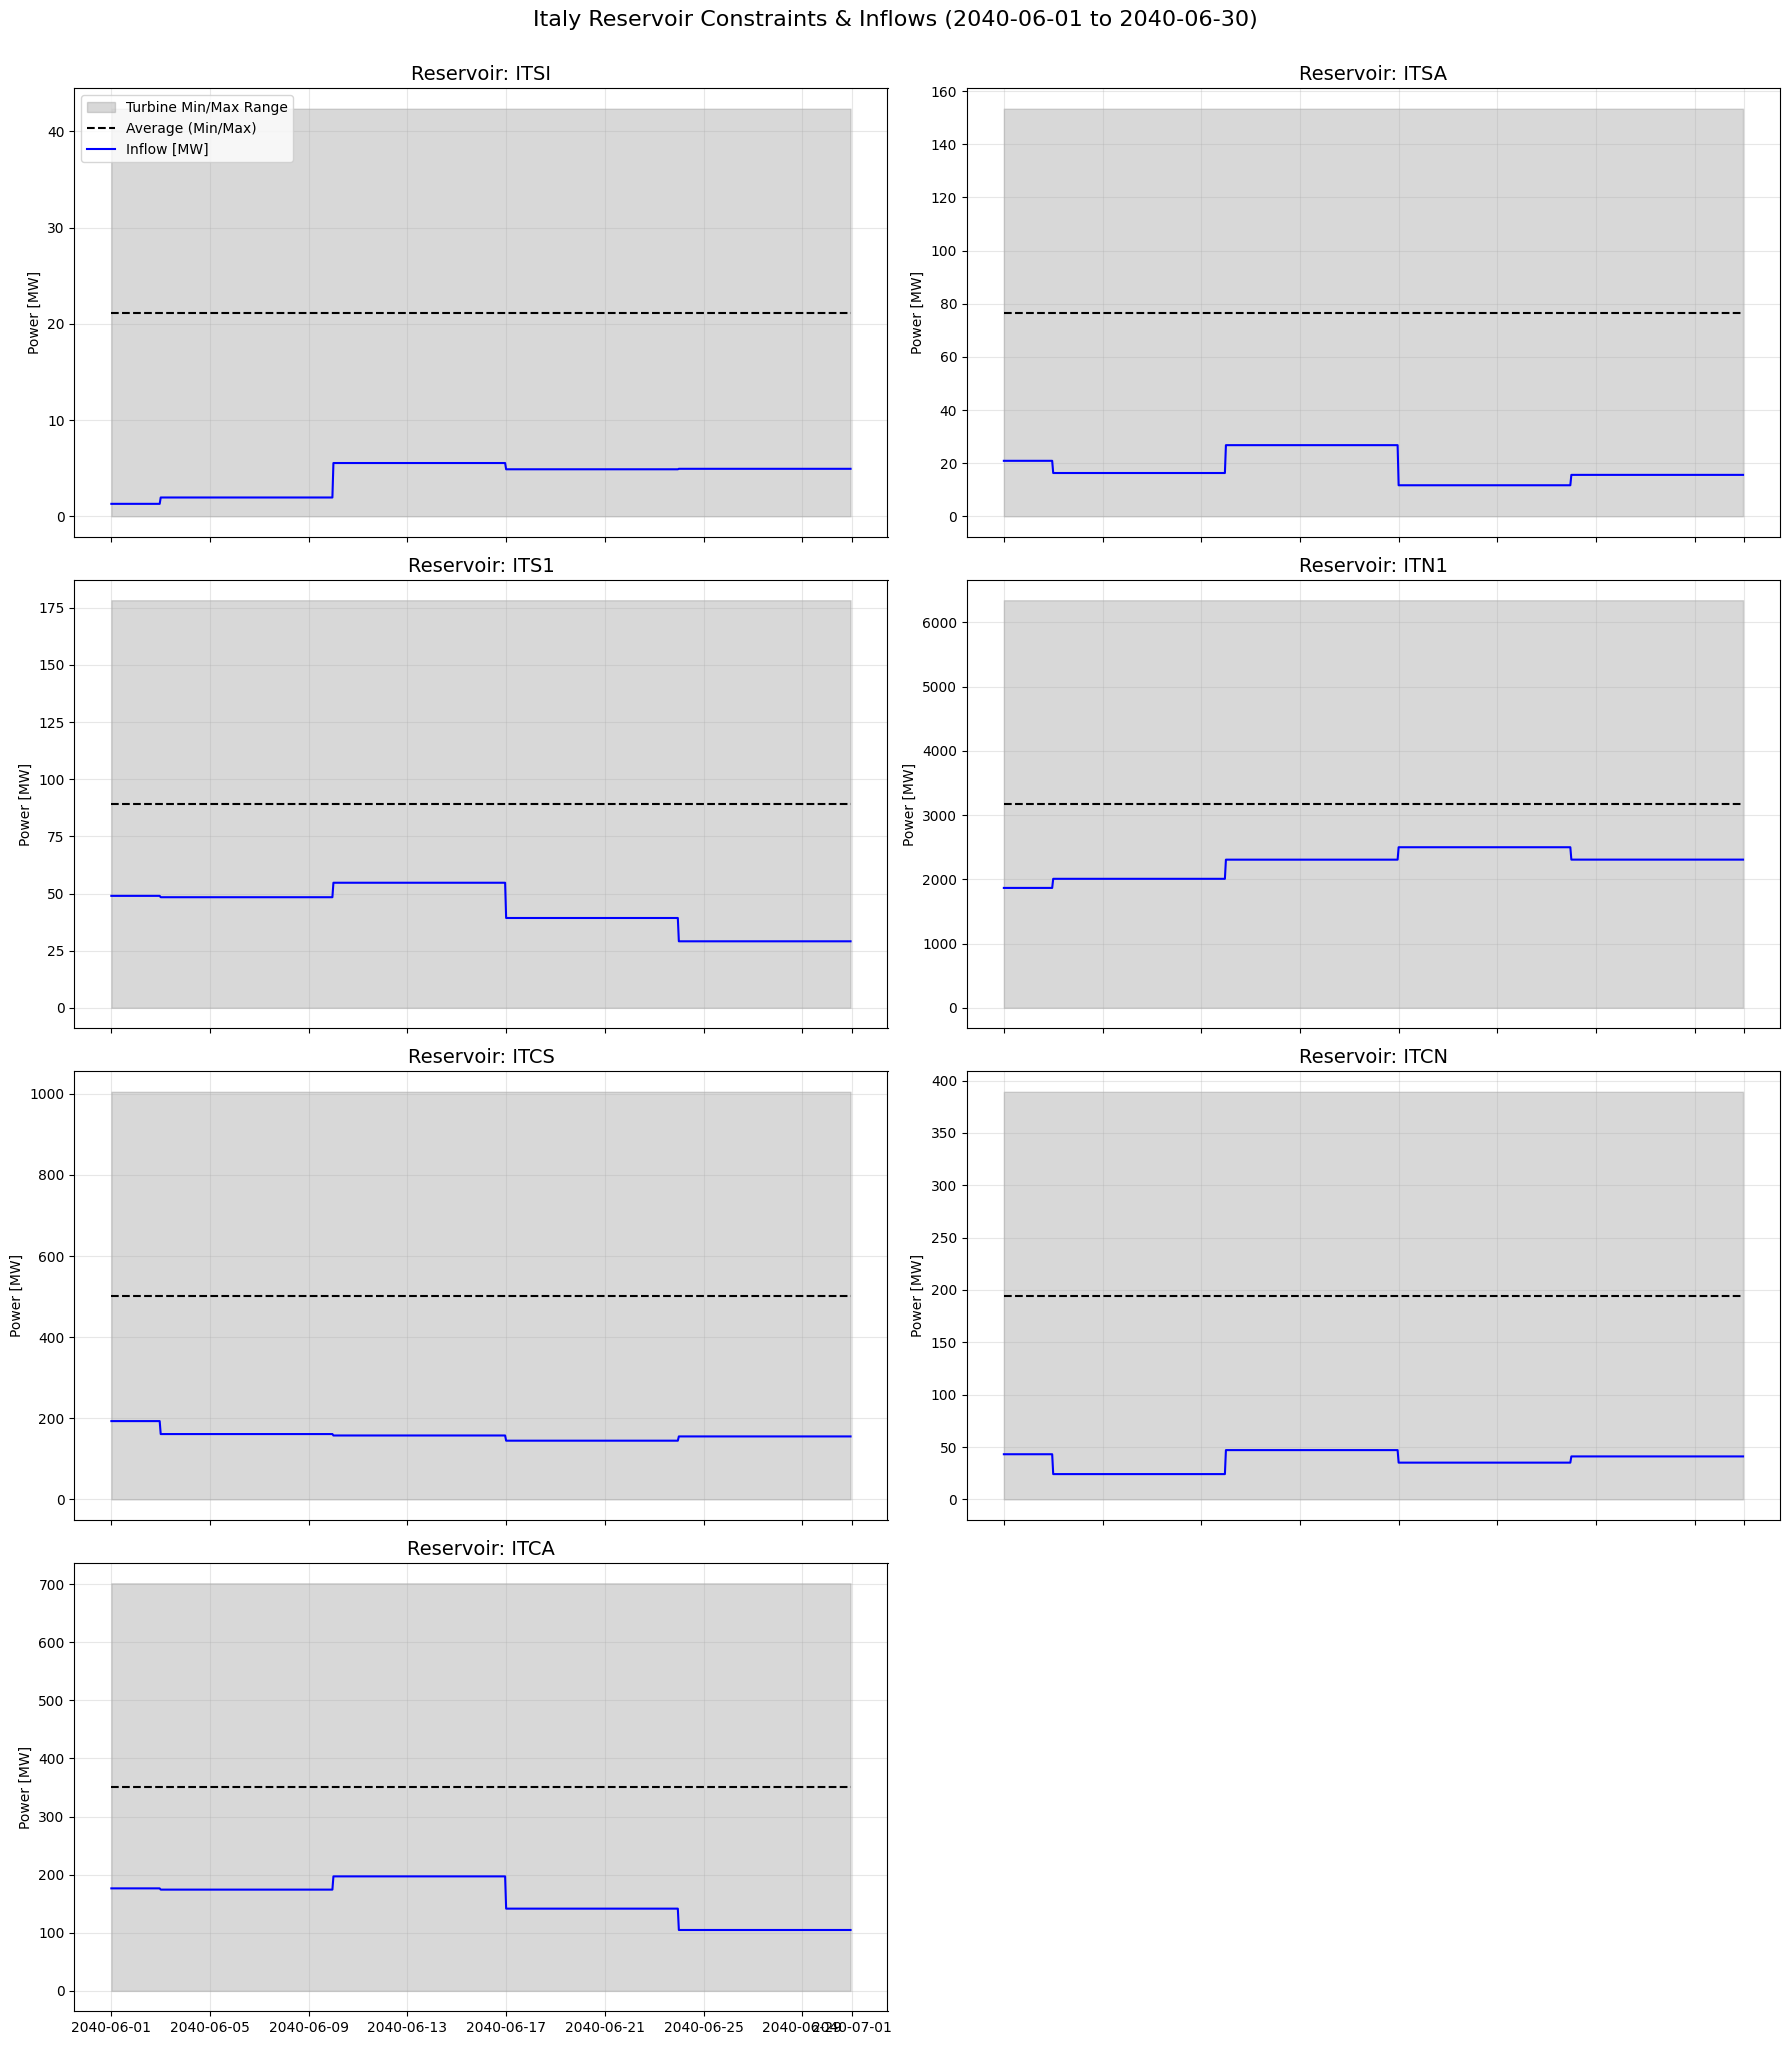

In [25]:
import matplotlib.pyplot as plt

# Set up a grid for all 7 zones
fig, axes = plt.subplots(4, 2, figsize=(18, 20), sharex=True)
axes = axes.flatten()

# Use a specific time window for better visibility (e.g., June 2040)
start_p = '2040-06-01'
end_p = '2040-06-30'
plot_sample = reservoir_profiles_df.loc[start_p:end_p]

for i, zone in enumerate(italian_zones):
    ax = axes[i]

    min_mw = plot_sample[f'{zone}_Res_Min_MW']
    max_mw = plot_sample[f'{zone}_Res_Max_MW']
    avg_mw = (min_mw + max_mw) / 2
    inflow_mw = plot_sample[f'{zone}_Res_Inflow_MW']

    # Plot Turbine Constraints as a grey shaded area
    ax.fill_between(plot_sample.index, min_mw, max_mw,
                    color='grey', alpha=0.3, label='Turbine Min/Max Range')

    # Plot the average between min and max as a line
    ax.plot(plot_sample.index, avg_mw,
            color='black', linestyle='--', linewidth=1.5, label='Average (Min/Max)')

    # Plot Inflow for context
    ax.plot(plot_sample.index, inflow_mw,
            color='blue', linewidth=1.5, label='Inflow [MW]')

    ax.set_title(f"Reservoir: {zone}", fontsize=14)
    ax.set_ylabel("Power [MW]")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc='upper left')

# Remove the empty 8th subplot
fig.delaxes(axes[7])

plt.tight_layout()
plt.suptitle(f"Italy Reservoir Constraints & Inflows ({start_p} to {end_p})", fontsize=16, y=1.02)
plt.show()


## Electricity Profile from Hystorical Profiles

In [26]:
# Electricity Demand Profiles
import pandas as pd
import os

demand_profiles_2040 = pd.DataFrame()
try:
    # 1. Load the specific sheet
    demand_file_path = os.path.join(PROJECT_DIR, "2040_National Trends.xlsx")

    for zone in italian_zones:
        try:
            df_demand_full = pd.read_excel(demand_file_path, sheet_name=zone)

            # 2. Identify the column for the selected weather year (located at row index 6)
            header_row = df_demand_full.iloc[6]
            try:
                # Exact float match
                col_idx = header_row[header_row == float(weather_profile)].index[0]
            except:
                # String-based fallback match
                col_idx = header_row[header_row.astype(str).str.contains(str(int(float(weather_profile))))].index[0]

            col_pos = df_demand_full.columns.get_loc(col_idx)

            # 3. Extract hourly data starting from row index 7
            raw_shape = df_demand_full.iloc[7:, col_pos].astype(float).reset_index(drop=True)

            # 4. We temporarily assume the raw shape represents the zone demand without scaling
            # (or we can scale if a specific zonal target is known later)
            elec_profile_2040 = raw_shape

            demand_profiles_2040[zone] = elec_profile_2040

            print(f"✅ Processed 2040 demand for {zone} using {weather_profile} weather shape.")
            print(f"  - Peak Demand:   {elec_profile_2040.max():.2f} MW")
        except Exception as e:
            print(f"❌ Error processing demand for {zone}: {e}")

except Exception as e:
    print(f"❌ Error loading demand file: {e}")


✅ Processed 2040 demand for ITSI using 2010.0 weather shape.
  - Peak Demand:   5024.81 MW
✅ Processed 2040 demand for ITSA using 2010.0 weather shape.
  - Peak Demand:   2458.71 MW
✅ Processed 2040 demand for ITS1 using 2010.0 weather shape.
  - Peak Demand:   5351.58 MW
✅ Processed 2040 demand for ITN1 using 2010.0 weather shape.
  - Peak Demand:   41557.74 MW
✅ Processed 2040 demand for ITCS using 2010.0 weather shape.
  - Peak Demand:   12862.40 MW
✅ Processed 2040 demand for ITCN using 2010.0 weather shape.
  - Peak Demand:   5780.21 MW
✅ Processed 2040 demand for ITCA using 2010.0 weather shape.
  - Peak Demand:   1301.23 MW


In [27]:
# Target length for Leap Year 2040
target_hours = 8784

demand_profiles_8784 = pd.DataFrame()

for zone in demand_profiles_2040.columns:
    elec_profile_2040 = demand_profiles_2040[zone]
    # Convert to numpy array and pad to 8784 hours
    # Using 'edge' mode to repeat the last values for the missing 24 hours
    elec_values_8784 = np.pad(elec_profile_2040.values, (0, target_hours - len(elec_profile_2040)), mode='edge')

    # Create a new Series with the correct leap year index
    time_index_8784 = pd.date_range(start='2040-01-01 00:00', periods=target_hours, freq='h')
    demand_profiles_8784[zone] = pd.Series(elec_values_8784, index=time_index_8784)

print(f"✅ Electricity demand profiles extended to {target_hours} hours for {len(demand_profiles_8784.columns)} zones.")


✅ Electricity demand profiles extended to 8784 hours for 7 zones.


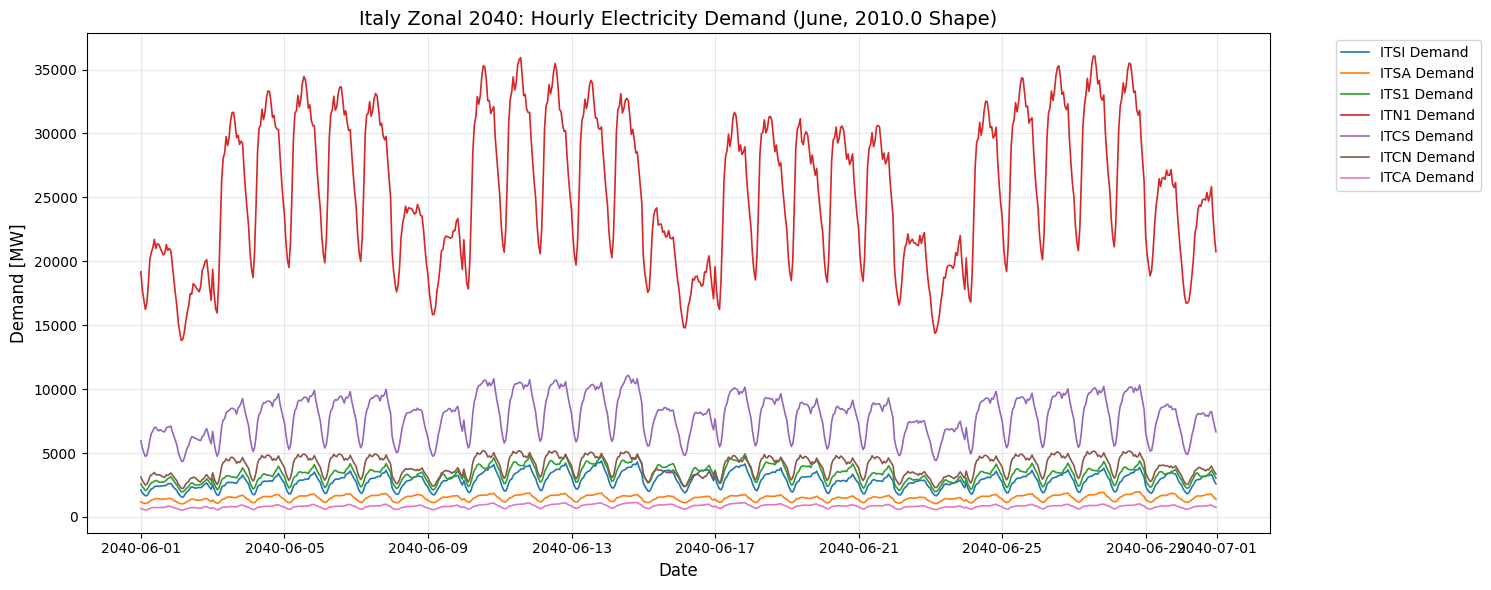

In [28]:
import matplotlib.pyplot as plt

# Filter for the month of June for visual verification
demand_june = demand_profiles_8784.loc['2040-06-01':'2040-06-30']

plt.figure(figsize=(15, 6))
for zone in demand_profiles_8784.columns:
    plt.plot(demand_june.index, demand_june[zone], linewidth=1.2, label=f'{zone} Demand')

plt.title(f'Italy Zonal 2040: Hourly Electricity Demand (June, {weather_profile} Shape)', fontsize=14)
plt.ylabel('Demand [MW]', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Summary data

We want to summaries this code by saving two files:

1.  All profiles into Italy_profiles_2040
2.  Save capacities dictionary to json



In [29]:
print("--- Summary of Available Hourly Profiles (8784 hours) ---")

hourly_dataframes = {
    "Solar PV": solar_profiles_df,
    "Wind": wind_profiles_df,
    "Hydro Run-of-River": ror_inflow_df,
    "Hydro Pondage": pondage_inflow_df,
    "Hydro Reservoir": reservoir_profiles_df,
    "Electricity Demand": demand_profiles_8784
}

for name, df in hourly_dataframes.items():
    if df is not None and not df.empty:
        print(f"\n> {name} Profiles:")
        print(f"  Shape: {df.shape}")
        # Print first few columns and indicate if there are more
        cols = list(df.columns)
        if len(cols) > 5:
            print(f"  Columns: {cols[:5]} ... (+ {len(cols) - 5} more)")
        else:
            print(f"  Columns: {cols}")
    else:
        print(f"\n> {name} Profiles:\n  Empty or not available.")

--- Summary of Available Hourly Profiles (8784 hours) ---

> Solar PV Profiles:
  Shape: (8784, 14)
  Columns: ['ITSI_Rooftop_PV', 'ITSI_Utility_PV', 'ITSA_Rooftop_PV', 'ITSA_Utility_PV', 'ITS1_Rooftop_PV'] ... (+ 9 more)

> Wind Profiles:
  Shape: (8784, 14)
  Columns: ['ITSI_Wind_Onshore', 'ITSI_Wind_Offshore', 'ITSA_Wind_Onshore', 'ITSA_Wind_Offshore', 'ITS1_Wind_Onshore'] ... (+ 9 more)

> Hydro Run-of-River Profiles:
  Shape: (8784, 7)
  Columns: ['ITSI_RoR_Inflow_pu', 'ITSA_RoR_Inflow_pu', 'ITS1_RoR_Inflow_pu', 'ITN1_RoR_Inflow_pu', 'ITCS_RoR_Inflow_pu'] ... (+ 2 more)

> Hydro Pondage Profiles:
  Empty or not available.

> Hydro Reservoir Profiles:
  Shape: (8784, 21)
  Columns: ['ITSI_Res_Min_MW', 'ITSI_Res_Max_MW', 'ITSI_Res_Inflow_MW', 'ITSA_Res_Min_MW', 'ITSA_Res_Max_MW'] ... (+ 16 more)

> Electricity Demand Profiles:
  Shape: (8784, 7)
  Columns: ['ITSI', 'ITSA', 'ITS1', 'ITN1', 'ITCS'] ... (+ 2 more)


In [30]:
import pandas as pd
import numpy as np

# Create the 8784-hour index for the 2040 leap year
time_index_8784 = pd.date_range(start="2040-01-01 00:00", periods=8784, freq="h")
other_res_profiles_df = pd.DataFrame(index=time_index_8784)

for zone in italian_zones:
    if 'Other RES' in capacities[zone] and 'profile' in capacities[zone]['Other RES']:
        # Extract the 8760-hour profile values
        profile_8760 = capacities[zone]['Other RES']['profile'].values

        # Extrapolate for Feb 29 (Leap year: duplicate Feb 28th)
        feb_29_start = 59 * 24
        feb_28_start = 58 * 24
        feb_28_data = profile_8760[feb_28_start : feb_28_start + 24]

        profile_8784 = np.zeros(8784)
        profile_8784[:feb_29_start] = profile_8760[:feb_29_start]
        profile_8784[feb_29_start : feb_29_start + 24] = feb_28_data
        profile_8784[feb_29_start + 24 :] = profile_8760[feb_28_start + 24 :]

        # Add to the DataFrame with the requested column name
        col_name = f"{zone}_Other_RES"
        other_res_profiles_df[col_name] = profile_8784

print(f"✅ 'Other RES' profiles processed and extrapolated to leap year. Shape: {other_res_profiles_df.shape}")
display(other_res_profiles_df.head())


✅ 'Other RES' profiles processed and extrapolated to leap year. Shape: (8784, 7)


,ITSI_Other_RES,ITSA_Other_RES,ITS1_Other_RES,ITN1_Other_RES,ITCS_Other_RES,ITCN_Other_RES,ITCA_Other_RES
2040-01-01 00:00:00,55.289,59.267502,265.999998,1361.5841,327.725283,786.1428,107.484
2040-01-01 01:00:00,55.289,59.267502,265.999998,1361.5841,327.725283,786.1428,107.484
2040-01-01 02:00:00,55.289,59.267502,265.999998,1361.5841,327.725283,786.1428,107.484
2040-01-01 03:00:00,55.289,59.267502,265.999998,1361.5841,327.725283,786.1428,107.484
2040-01-01 04:00:00,55.289,59.267502,265.999998,1361.5841,327.725283,786.1428,107.484


In [31]:
import pandas as pd

# Rename demand columns to have a clear suffix before merging
demand_renamed = demand_profiles_8784.add_suffix('_Demand')

# List of all dataframes to merge
dfs_to_merge = [
    solar_profiles_df,
    wind_profiles_df,
    ror_inflow_df,
    reservoir_profiles_df,
    demand_renamed,
    other_res_profiles_df
]

# Concatenate all dataframes along the columns (axis=1)
Italy_profile = pd.concat(dfs_to_merge, axis=1)

print(f"✅ Successfully merged all profiles into 'Italy_profile'.")
print(f"Final Shape: {Italy_profile.shape}")
display(Italy_profile.head())

✅ Successfully merged all profiles into 'Italy_profile'.
Final Shape: (8784, 70)


,ITSI_Rooftop_PV,ITSI_Utility_PV,ITSA_Rooftop_PV,ITSA_Utility_PV,ITS1_Rooftop_PV,ITS1_Utility_PV,ITN1_Rooftop_PV,ITN1_Utility_PV,ITCS_Rooftop_PV,ITCS_Utility_PV,...,ITCS_Demand,ITCN_Demand,ITCA_Demand,ITSI_Other_RES,ITSA_Other_RES,ITS1_Other_RES,ITN1_Other_RES,ITCS_Other_RES,ITCN_Other_RES,ITCA_Other_RES
2040-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5248.479617,2525.510190,790.960592,55.289,59.267502,265.999998,1361.5841,327.725283,786.1428,107.484
2040-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4554.997948,2239.189659,702.641199,55.289,59.267502,265.999998,1361.5841,327.725283,786.1428,107.484
2040-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4095.344911,2072.201833,640.675359,55.289,59.267502,265.999998,1361.5841,327.725283,786.1428,107.484
2040-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3839.584775,1921.170178,598.735136,55.289,59.267502,265.999998,1361.5841,327.725283,786.1428,107.484
2040-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3722.509118,1875.587687,585.502102,55.289,59.267502,265.999998,1361.5841,327.725283,786.1428,107.484


In [32]:
Italy_profile.columns

Index(['ITSI_Rooftop_PV', 'ITSI_Utility_PV', 'ITSA_Rooftop_PV',
       'ITSA_Utility_PV', 'ITS1_Rooftop_PV', 'ITS1_Utility_PV',
       'ITN1_Rooftop_PV', 'ITN1_Utility_PV', 'ITCS_Rooftop_PV',
       'ITCS_Utility_PV', 'ITCN_Rooftop_PV', 'ITCN_Utility_PV',
       'ITCA_Rooftop_PV', 'ITCA_Utility_PV', 'ITSI_Wind_Onshore',
       'ITSI_Wind_Offshore', 'ITSA_Wind_Onshore', 'ITSA_Wind_Offshore',
       'ITS1_Wind_Onshore', 'ITS1_Wind_Offshore', 'ITN1_Wind_Onshore',
       'ITN1_Wind_Offshore', 'ITCS_Wind_Onshore', 'ITCS_Wind_Offshore',
       'ITCN_Wind_Onshore', 'ITCN_Wind_Offshore', 'ITCA_Wind_Onshore',
       'ITCA_Wind_Offshore', 'ITSI_RoR_Inflow_pu', 'ITSA_RoR_Inflow_pu',
       'ITS1_RoR_Inflow_pu', 'ITN1_RoR_Inflow_pu', 'ITCS_RoR_Inflow_pu',
       'ITCN_RoR_Inflow_pu', 'ITCA_RoR_Inflow_pu', 'ITSI_Res_Min_MW',
       'ITSI_Res_Max_MW', 'ITSI_Res_Inflow_MW', 'ITSA_Res_Min_MW',
       'ITSA_Res_Max_MW', 'ITSA_Res_Inflow_MW', 'ITS1_Res_Min_MW',
       'ITS1_Res_Max_MW', 'ITS1_Res_Inflow

In [33]:
import os

file_path = os.path.join(PROJECT_DIR, "Italy")

# Ensure the directory exists
os.makedirs(file_path, exist_ok=True)

# Define the file path in the project directory
csv_file_path = os.path.join(file_path, "Italy_profile_2040.csv")

# Save the dataframe to CSV
Italy_profile.to_csv(csv_file_path)

print(f"✅ Dataframe successfully saved to: {csv_file_path}")

✅ Dataframe successfully saved to: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/data/Italy/Italy_profile_2040.csv


In [34]:
import json
import os

# 1. Delete 'profile' from 'Other RES' in the capacities dictionary
for zone in capacities:
    if 'Other RES' in capacities[zone] and 'profile' in capacities[zone]['Other RES']:
        del capacities[zone]['Other RES']['profile']

print("✅ Successfully deleted 'Other RES' profiles from the capacities dictionary.")

# 2. Save the updated capacities dictionary to a JSON file
file_path = os.path.join(PROJECT_DIR, "Italy")
os.makedirs(file_path, exist_ok=True)

json_file_path = os.path.join(file_path, "Italian_capacities_2040.json")

with open(json_file_path, 'w') as f:
    json.dump(capacities, f, indent=4)

print(f"✅ Updated capacities successfully saved to: {json_file_path}")

✅ Successfully deleted 'Other RES' profiles from the capacities dictionary.
✅ Updated capacities successfully saved to: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/data/Italy/Italian_capacities_2040.json
